In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor

from econml.dml import LinearDML, CausalForestDML
from haversine import haversine, Unit
import shap

In [144]:
df = pd.read_csv('olist_dataset.csv')
pd.options.display.max_columns = None
pd.options.display.max_rows = 100
print(df.shape)
pd.options.display.max_columns = None

(113425, 35)


In [145]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng',
       'product_category_name_english', 'payment_value'],
      dtype='str')

In [146]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 35 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113425 non-null  str    
 1   customer_id                    113425 non-null  str    
 2   order_status                   113425 non-null  str    
 3   order_purchase_timestamp       113425 non-null  str    
 4   order_approved_at              113264 non-null  str    
 5   order_delivered_carrier_date   111457 non-null  str    
 6   order_delivered_customer_date  110196 non-null  str    
 7   order_estimated_delivery_date  113425 non-null  str    
 8   customer_unique_id             113425 non-null  str    
 9   customer_zip_code_prefix       113425 non-null  int64  
 10  customer_city                  113425 non-null  str    
 11  customer_state                 113425 non-null  str    
 12  order_item_id                  112650 non

# EXPLORATORY DATA ANALYSIS AND FEATURE ENGINEERING

In [147]:
## drop and converting datatype of columns
df = df.drop_duplicates()


df = df.drop(columns = ['order_id', 'customer_id', 'order_status'])


df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
# df['shipping_limit_date'] = pd.to_datetime(df['shipping_limit_date'], format = '%d-%m-%Y %H:%M')
# handling time # Shipping SLA (days)
# df['shipping_sla_days'] = (df['shipping_limit_date'] - df['order_purchase_timestamp']).dt.total_seconds()/(24*3600)  #in days
# # Time components
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_day_of_week'] = df['order_purchase_timestamp'].dt.dayofweek
df['purchase_hour'] = df['order_purchase_timestamp'].dt.hour

df = df.drop(columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'product_name_lenght',
                        'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id'])


df['customer_state'].isnull().sum()

df = df.drop(columns = ['order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'product_category_name'])


## col 1 customer_zip_code_prefix
df = df.rename(columns = {'customer_zip_code_prefix' : 'customer_zip_code'})
df = df.rename(columns = {'seller_zip_code_prefix' : 'seller_zip_code'})

df['seller_state'].isnull().sum()

df['product_photos_qty'].isnull().sum()
df['product_photos_qty'] = df['product_photos_qty'].fillna(df.groupby('product_category_name_english')['product_photos_qty'].transform('median'))
df['product_photos_qty'].isnull().sum()


df['product_description_lenght'].isnull().sum()  # fill it by median of corresponding product_name group's median
df['product_description_lenght'] = df['product_description_lenght'].fillna(df.groupby('product_category_name_english')['product_description_lenght'].transform('median'))
df['product_description_lenght'].isnull().sum()

df['product_volume_cm3'] = df['product_description_lenght'] * df['product_length_cm'] * df['product_height_cm']
df = df.dropna(subset = ['product_description_lenght', 'product_length_cm', 'product_height_cm', 'product_width_cm'])

df = df.rename(columns = {'product_category_name_english' : 'product_category_name'})
category = {
            'food': 'Food_and_beverages',
            'drinks': 'Food_and_beverages',
            'food_drink': 'Food_and_beverages',
    
            'furniture_decor': 'Furniture',
            'furniture_bedroom': 'Furniture',
            'furniture_living_room': 'Furniture',
            'office_furniture': 'Furniture',
            'kitchen_dining_laundry_garden_furniture': 'Furniture',
    
            'bed_bath_table': 'Home_and_appliances',
            'housewares': 'Home_and_appliances',
            'la_cuisine': 'Home_and_appliances',
            'home_confort': 'Home_and_appliances',
            'home_comfort_2': 'Home_and_appliances',
            'home_appliances': 'Home_and_appliances',
            'home_appliances_2': 'Home_and_appliances',
            'small_appliances': 'Home_and_appliances',
            'small_appliances_home_oven_and_coffee': 'Home_and_appliances',
            'air_conditioning': 'Home_and_appliances',

            'computers': 'Electronics',
            'computers_accessories': 'Electronics',
            'electronics': 'Electronics',
            'telephony': 'Electronics',
            'fixed_telephony': 'Electronics',
            'audio': 'Electronics',
            'cine_photo': 'Electronics',
            'tablets_printing_image': 'Electronics',
            'consoles_games': 'Electronics',

            'fashion_bags_accessories': 'Fashion_and_accessories',
            'fashion_male_clothing': 'Fashion_and_accessories',
            'fashion_shoes': 'Fashion_and_accessories',
            'fashion_sport': 'Fashion_and_accessories',
            'fashion_underwear_beach': 'Fashion_and_accessories',
            'luggage_accessories': 'Fashion_and_accessories',
            'watches_gifts': 'Fashion_and_accessories',

            'health_beauty': 'Health_and_beauty',
            'perfumery': 'Health_and_beauty',

            'baby': 'Leisure_and_hobbies', 'toys': 'Leisure_and_hobbies',
            'sports_leisure': 'Leisure_and_hobbies', 'pet_shop': 'Leisure_and_hobbies',
            'art': 'Leisure_and_hobbies', 'books_general_interest': 'Leisure_and_hobbies',
            'books_technical': 'Leisure_and_hobbies', 'cds_dvds_musicals': 'Leisure_and_hobbies',
            'dvds_blu_ray': 'Leisure_and_hobbies', 'musical_instruments': 'Leisure_and_hobbies',
            'stationery': 'Leisure_and_hobbies', 'party_supplies': 'Leisure_and_hobbies',
            'christmas_supplies': 'Leisure_and_hobbies', 'cool_stuff': 'Leisure_and_hobbies',

            'construction_tools_construction': 'Tools_and_Garden', 'construction_tools_lights': 'Tools_and_Garden',
            'construction_tools_safety': 'Tools_and_Garden', 'costruction_tools_tools': 'Tools_and_Garden',
            'costruction_tools_garden': 'Tools_and_Garden', 'garden_tools': 'Tools_and_Garden',
            'home_construction': 'Tools_and_Garden', 'flowers': 'Tools_and_Garden',

            'auto': 'Automotive_and_B2B',
            'agro_industry_and_commerce': 'Automotive_and_B2B',
            'industry_commerce_and_business': 'Automotive_and_B2B',
            'market_place': 'Automotive_and_B2B'
         }
df['product_category_name'] = df['product_category_name'].map(category).fillna('Other')

df['product_category_name'].value_counts()


df['is_same_city'] = (df['customer_city'].str.lower() == df['seller_city'].str.lower()).astype(int)
df['is_same_state'] = (df['customer_state'].str.lower() == df['seller_state'].str.lower()).astype(int)
df['product_volume_cm3'] = df['product_length_cm']*df['product_height_cm']*df['product_width_cm']


## customer lat
df['customer_lat'].isnull().sum()
df['customer_lat'] = df['customer_lat'].fillna(df.groupby('customer_zip_code')['customer_lat'].transform('median'))
# print(df['customer_lat'].isnull().sum())

# drop the null values of customer_lat
df = df.dropna(subset=['customer_lat'])

df['customer_lat'].isnull().sum()

## seller lat
df['seller_lat'].isnull().sum()
#1 fiil by median of corresponding group of zip-code
df['seller_lat'] = df['seller_lat'].fillna(df.groupby('seller_zip_code')['seller_lat'].transform('median'))
# print(df['seller_lat'].isnull().sum())
df = df.dropna(subset = ['seller_lat'])
df['seller_lat'].isnull().sum()
df['seller_lng'].isnull().sum()

from haversine import haversine, Unit

def distance(x):
    customer_location = (x['customer_lat'], x['customer_lng'])
    seller_location = (x['seller_lat'], x['seller_lng'])

    return haversine(customer_location, seller_location, unit=Unit.KILOMETERS)
df['distance_km'] = df.apply(distance, axis = 1)


df = df.drop(columns = ['customer_state', 'customer_city', 'seller_zip_code', 'customer_zip_code', 'seller_lat', 'seller_lng', 
     'customer_lat', 'customer_lng', 'product_height_cm', 'product_width_cm', 'product_length_cm', 'seller_city', 'seller_state'])
df = df.dropna(subset=['payment_value'])
# df = df.drop(columns = ['shipping_sla_days'])

# print(df['price'].isnull().sum())
# print(df['freight_value'].isnull().sum())
# print(df['product_description_lenght'].isnull().sum())
# print(df['product_photos_qty'].isnull().sum())
# print(df['product_weight_g'].isnull().sum())
# print(df['product_category_name'].isnull().sum())
# print(df['payment_value'].isnull().sum())
# print(df['shipping_sla_days'].isnull().sum())
# print(df['shipping_sla_days'].isnull().sum())
# print(df['purchase_day_of_week'].isnull().sum())
# print(df['purchase_hour'].isnull().sum())
# print(df['product_volume_cm3'].isnull().sum())
# print(df['is_same_city'].isnull().sum())
# print(df['is_same_state'].isnull().sum())

df.columns

Index(['price', 'freight_value', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_category_name',
       'payment_value', 'purchase_month', 'purchase_day_of_week',
       'purchase_hour', 'product_volume_cm3', 'is_same_city', 'is_same_state',
       'distance_km'],
      dtype='str')

In [148]:
df.info()

<class 'pandas.DataFrame'>
Index: 110496 entries, 0 to 113424
Data columns (total 14 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   price                       110496 non-null  float64
 1   freight_value               110496 non-null  float64
 2   product_description_lenght  110496 non-null  float64
 3   product_photos_qty          110496 non-null  float64
 4   product_weight_g            110496 non-null  float64
 5   product_category_name       110496 non-null  str    
 6   payment_value               110496 non-null  float64
 7   purchase_month              110496 non-null  int32  
 8   purchase_day_of_week        110496 non-null  int32  
 9   purchase_hour               110496 non-null  int32  
 10  product_volume_cm3          110496 non-null  float64
 11  is_same_city                110496 non-null  int64  
 12  is_same_state               110496 non-null  int64  
 13  distance_km                 11

# VISUALIZATION ON CLEANED DATA

### UNIVARIATE ANALYSIS

count    110496.000000
mean        120.791925
std         183.538505
min           0.850000
25%          39.900000
50%          74.980000
75%         134.975000
max        6735.000000
Name: price, dtype: float64


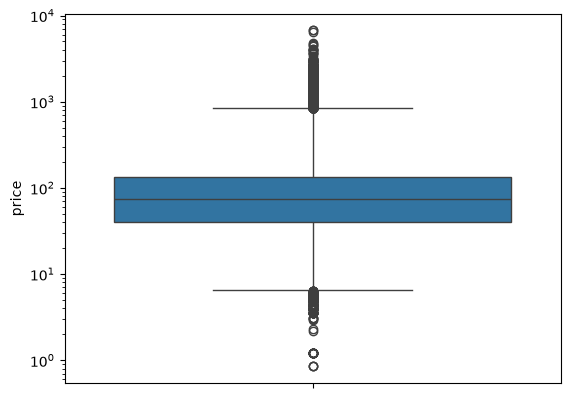

In [149]:
print(df['price'].describe())
sns.boxplot(df['price'], log_scale = True)
plt.show()

count    110496.000000
mean         20.017932
std          15.854000
min           0.000000
25%          13.080000
50%          16.290000
75%          21.180000
max         409.680000
Name: freight_value, dtype: float64


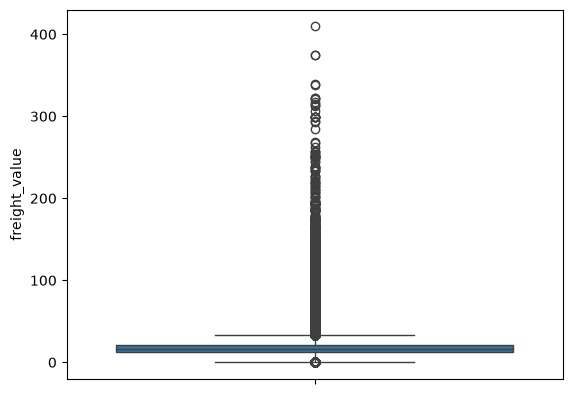

In [150]:
print(df['freight_value'].describe())
sns.boxplot(df['freight_value'])
plt.show()

count    110496.000000
mean        180.631645
std         273.670655
min           9.590000
25%          65.710000
50%         114.330000
75%         195.910000
max       13664.080000
Name: payment_value, dtype: float64


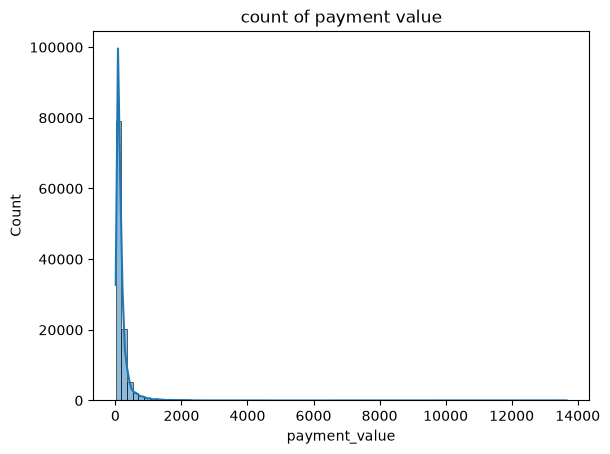

In [151]:
print(df['payment_value'].describe())
sns.histplot(df['payment_value'], kde = True, bins = 80)
plt.title('count of payment value')
plt.show()

count    110496.000000
mean        597.430953
std         589.985374
min           0.000000
25%         185.839038
50%         432.129024
75%         792.420172
max        8677.923608
Name: distance_km, dtype: float64


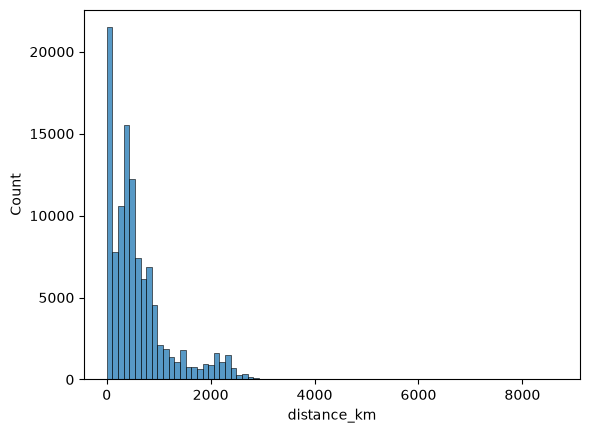

In [152]:
print(df['distance_km'].describe())
sns.histplot(df['distance_km'], bins = 80)
plt.show()

product_category_name
Leisure_and_hobbies        25918
Home_and_appliances        20566
Electronics                17108
Health_and_beauty          13042
Furniture                  10840
Fashion_and_accessories     9632
Tools_and_Garden            6733
Automotive_and_B2B          5016
Food_and_beverages          1164
Other                        477
Name: count, dtype: int64


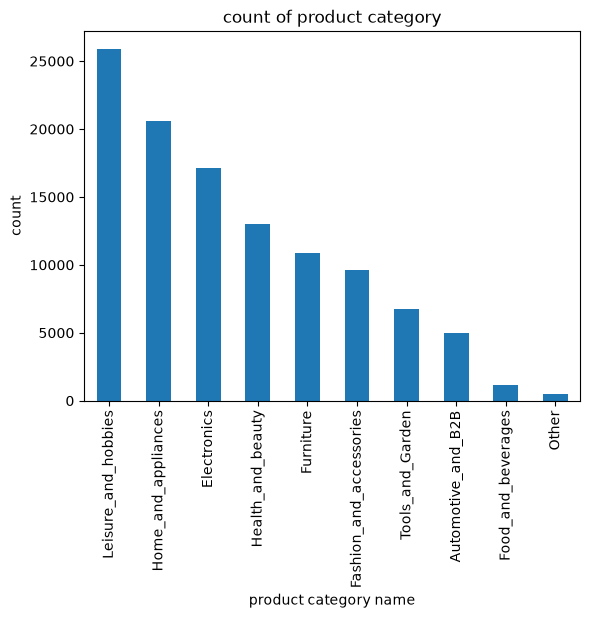

In [153]:
print(df['product_category_name'].value_counts())
df['product_category_name'].value_counts().plot(kind = 'bar')
plt.title('count of product category')
plt.xlabel('product category name')
plt.ylabel('count')
plt.show()

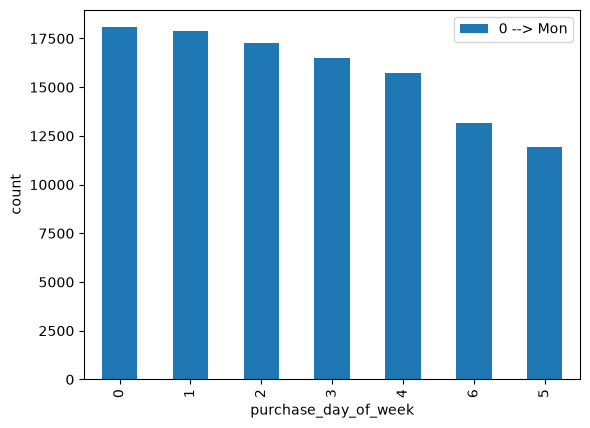

In [154]:
df['purchase_day_of_week'].value_counts().plot(kind = 'bar', label = '0 --> Mon')
plt.ylabel('count')
plt.legend()
plt.show()

purchase_hour
0     2664
1     1263
2      573
3      306
4      240
5      207
6      544
7     1349
8     3322
9     5329
10    6887
11    7293
12    6671
13    7260
14    7432
15    7248
16    7495
17    6877
18    6416
19    6594
20    6766
21    6770
22    6419
23    4571
Name: count, dtype: int64


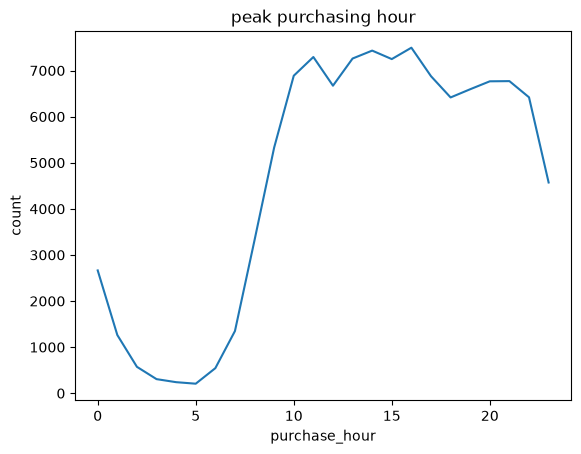

In [155]:
print(df['purchase_hour'].value_counts().sort_index())
df['purchase_hour'].value_counts().sort_index().plot(kind = 'line')
plt.title('peak purchasing hour')
plt.ylabel('count')
plt.show()

purchase_month
1      8902
2      9404
3     10972
4     10458
5     11861
6     10518
7     11456
8     11990
9      4736
10     5573
11     8499
12     6127
Name: count, dtype: int64


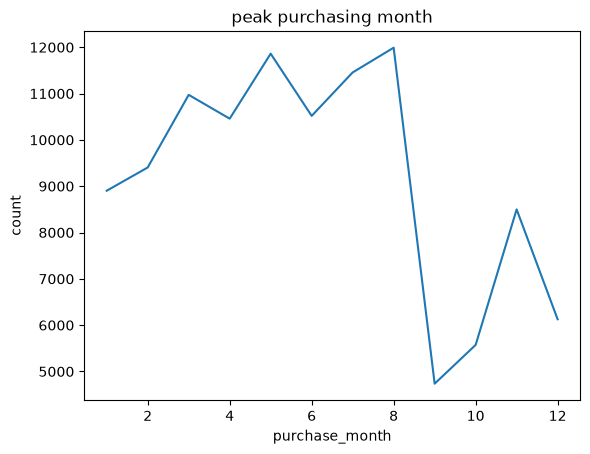

In [156]:
print(df['purchase_month'].value_counts().sort_index())
df['purchase_month'].value_counts().sort_index().plot(kind = 'line')
plt.title('peak purchasing month')
plt.ylabel('count')
plt.show()

is_same_city
0    104727
1      5769
Name: count, dtype: int64


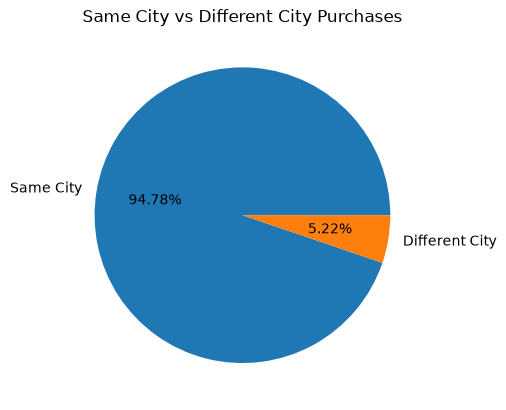

In [157]:
print(df['is_same_city'].value_counts())
df['is_same_city'].value_counts().plot(kind = 'pie', autopct = '%1.2f%%', labels=['Same City', 'Different City'])
plt.title('Same City vs Different City Purchases')
plt.show()      # 0 --> NO

### BIVARIATE ANALYSIS

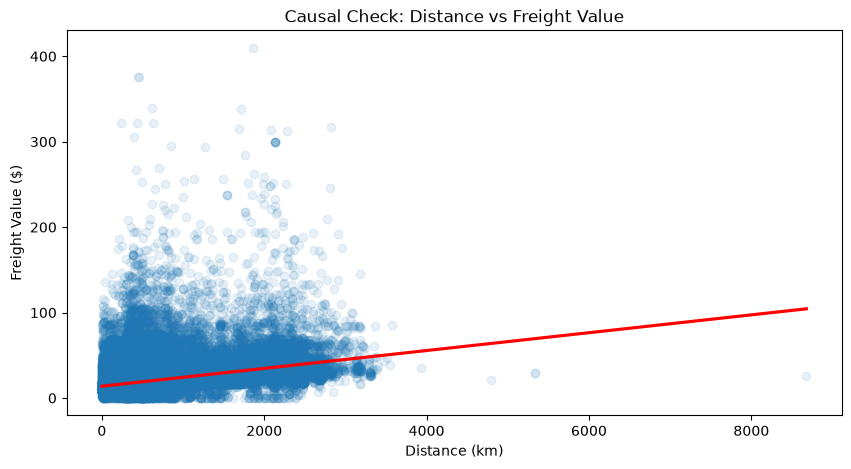

In [158]:
plt.figure(figsize = (10, 5))
sns.regplot(data = df, x = 'distance_km', y = 'freight_value', scatter_kws = {'alpha' : 0.1}, line_kws = {'color' : 'red'})
plt.title('Causal Check: Distance vs Freight Value')
plt.xlabel('Distance (km)')
plt.ylabel('Freight Value ($)')
plt.show()

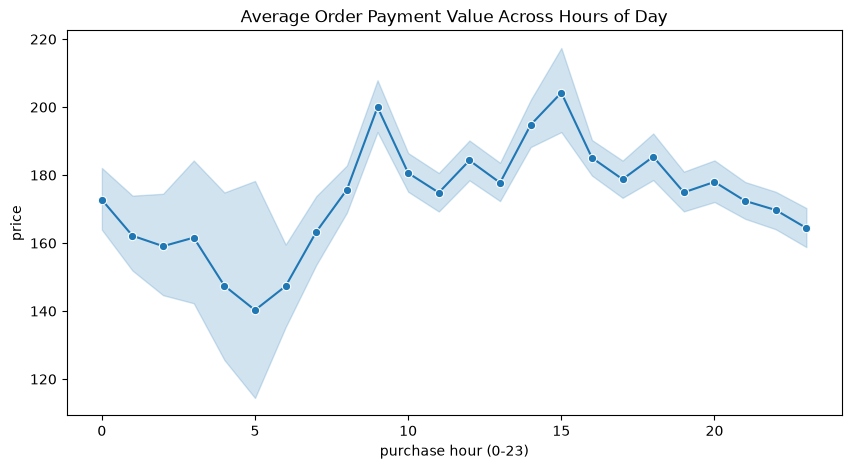

In [159]:
# Demand Pattern
plt.figure(figsize = (10, 5))
sns.lineplot(data = df, x = 'purchase_hour', y = 'payment_value', estimator = 'mean', marker = 'o')
plt.title('Average Order Payment Value Across Hours of Day')
plt.xlabel('purchase hour (0-23)')
plt.ylabel('price')
plt.show()

In [160]:
df.groupby('product_category_name')[['price', 'freight_value']].mean()

,price,freight_value
product_category_name,,
Automotive_and_B2B,145.926386,22.261968
Electronics,109.999792,17.818565
Fashion_and_accessories,159.553890,17.759231
Food_and_beverages,57.384785,14.999476
Furniture,104.640734,25.277545
Health_and_beauty,126.788954,18.096371
Home_and_appliances,107.615505,19.934980
Leisure_and_hobbies,125.242311,20.178517
Other,101.864927,24.424486


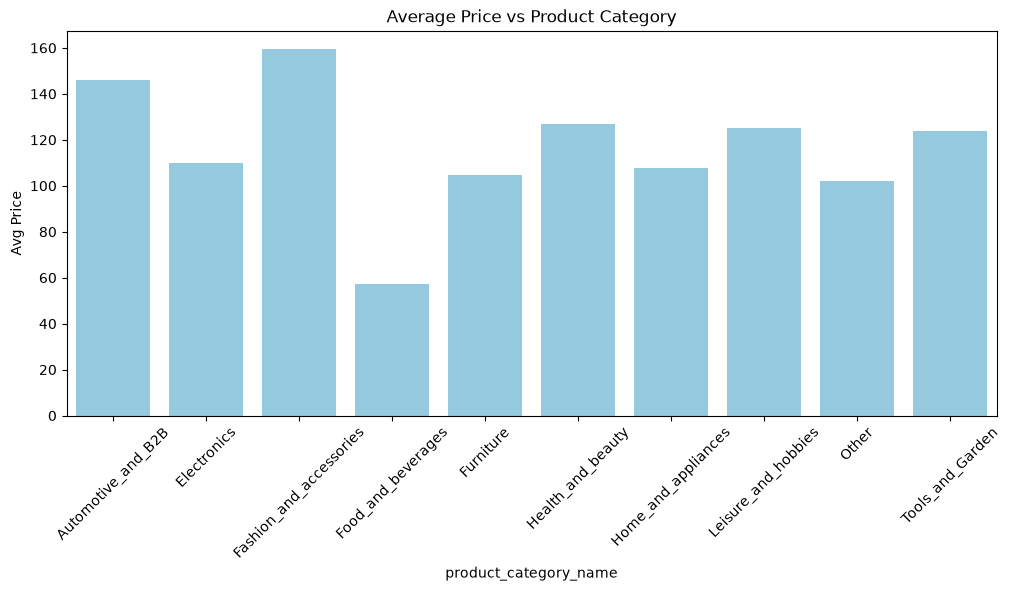

In [161]:
plt.figure(figsize = (12, 5))
cats_summary = df.groupby('product_category_name')[['price', 'freight_value']].mean()
sns.barplot(cats_summary, x = 'product_category_name', y = 'price', color = 'skyblue')
plt.title('Average Price vs Product Category')
plt.ylabel('Avg Price')
plt.xticks(rotation = 45)
plt.show()

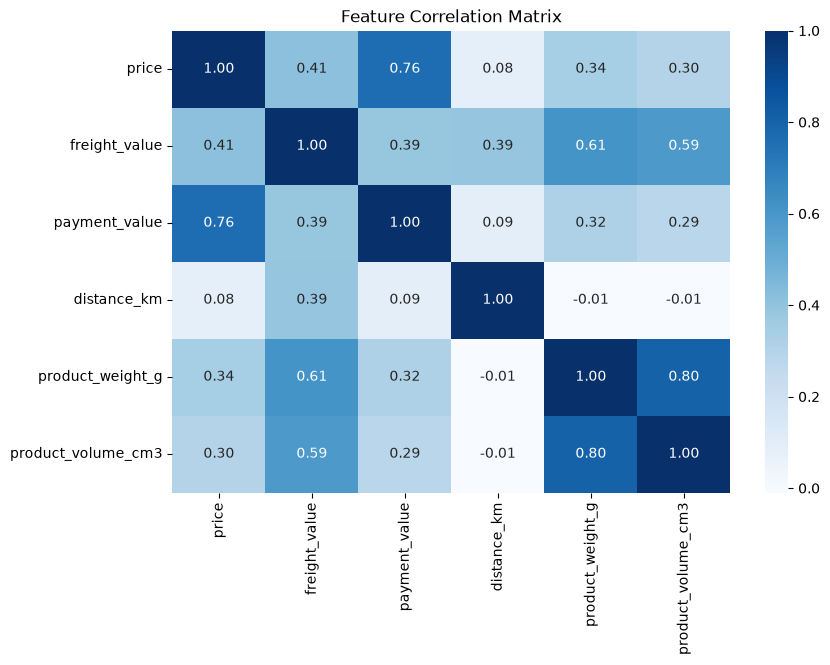

In [162]:
num_cols = ['price', 'freight_value', 'payment_value', 'distance_km', 'product_weight_g', 'product_volume_cm3']

plt.figure(figsize=(9, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

In [163]:
pd.crosstab(df['product_category_name'], df['is_same_state'], normalize = 'columns', margins = True)*100

is_same_state,0,1,All
product_category_name,,,
Automotive_and_B2B,4.464615,4.671056,4.539531
Electronics,16.857013,13.070477,15.482913
Fashion_and_accessories,8.896560,8.401915,8.717058
Food_and_beverages,0.849456,1.411542,1.053432
Furniture,9.724708,9.960597,9.810310
Health_and_beauty,11.672207,12.033019,11.803142
Home_and_appliances,16.918094,21.587112,18.612438
Leisure_and_hobbies,23.999261,22.502369,23.456053
Other,0.322452,0.623472,0.431690


In [164]:
pd.crosstab(df['is_same_city'], df['is_same_state'], normalize = 'columns', margins = True)*100

is_same_state,0,1,All
is_same_city,,,
0,99.978693,85.650157,94.778997
1,0.021307,14.349843,5.221003


### MULTIVARIATE ANALYSIS

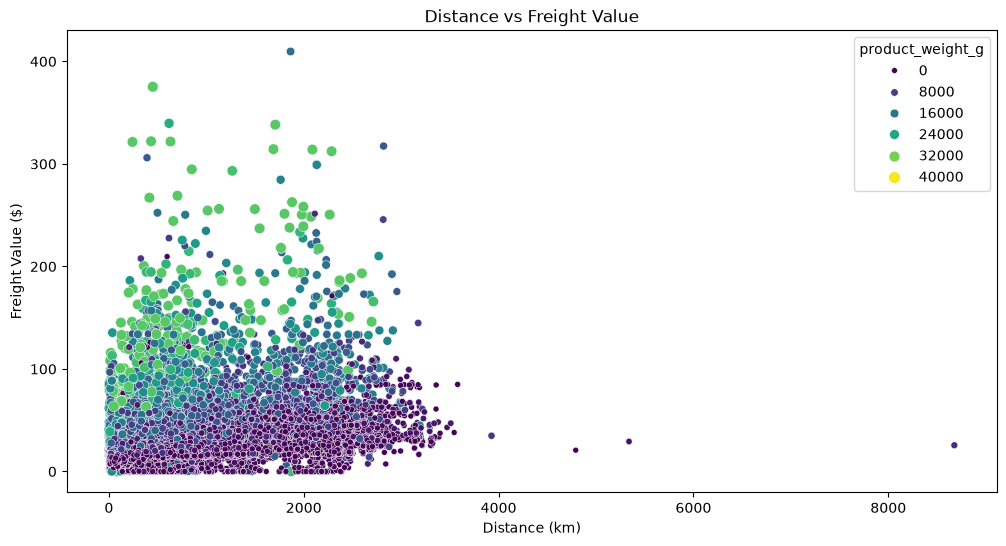

In [165]:
plt.figure(figsize = (12, 6))
sns.scatterplot(data = df, x = df['distance_km'], y = df['freight_value'], hue = 'product_weight_g', palette = 'viridis', 
                size = 'product_weight_g')
plt.title('Distance vs Freight Value')
plt.xlabel('Distance (km)')
plt.ylabel('Freight Value ($)')
plt.show()

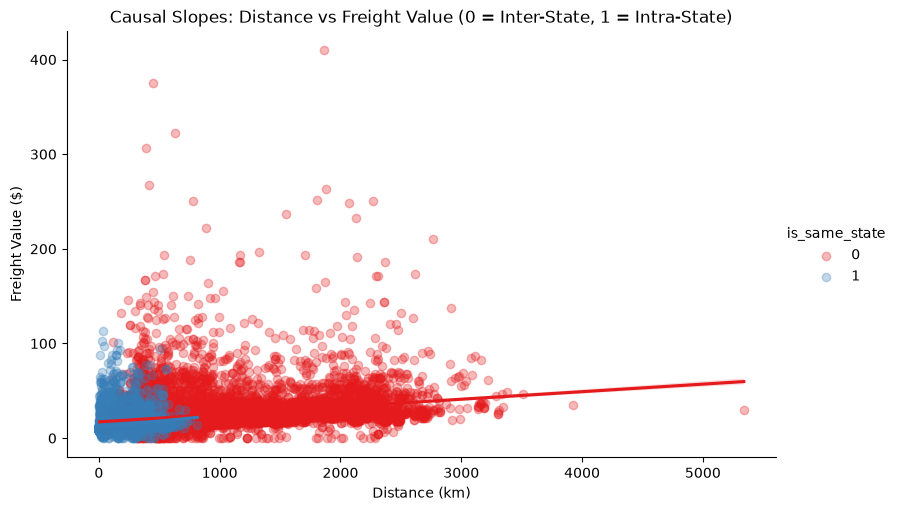

In [166]:
sns.lmplot(data=df.sample(20000, random_state=42), x='distance_km', y='freight_value', hue='is_same_state', palette='Set1',
           scatter_kws={'alpha': 0.3}, height=5, aspect=1.6,)
plt.title('Causal Slopes: Distance vs Freight Value (0 = Inter-State, 1 = Intra-State)')
plt.xlabel('Distance (km)')
plt.ylabel('Freight Value ($)')
plt.show()

# MODEL

In [167]:
# =========================================================
# STEP 3: CAUSAL VARIABLES DEFINE 
# =========================================================

print("\nDefining Causal Variables\n")

# Treatment (T) -->>> distance_km
T = df['distance_km'].values

# Outcomes (Y)  -->>> price, freight_vlaue, payment_value
outcomes = ['price', 'freight_value', 'payment_value']

# Confounders (X) -->> column except treatment and outcomes

X = df.drop(columns = ['price', 'freight_value', 'payment_value', 'distance_km'])
print(F"confounders : {X.columns.tolist}")
print(X.shape)



Defining Causal Variables

confounders : <bound method IndexOpsMixin.tolist of Index(['product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_category_name', 'purchase_month', 'purchase_day_of_week',
       'purchase_hour', 'product_volume_cm3', 'is_same_city', 'is_same_state'],
      dtype='str')>
(110496, 10)


In [168]:
# =========================================================
# STEP 4: TRAIN-TEST SPLIT & PREPROCESSING (ENCODING)
# =========================================================

from sklearn.model_selection import train_test_split
X_train, X_test, T_train, T_test = train_test_split(X, T, test_size= 0.2, random_state= 42)

X_train.index   # array

from sklearn.preprocessing import OneHotEncoder
cat_cols = ['product_category_name']
col_trans = ColumnTransformer(transformers = [
            ('cat', OneHotEncoder(handle_unknown= 'ignore', drop = 'first', sparse_output= False), cat_cols)
                                              ], remainder= 'passthrough')

X_train_final = col_trans.fit_transform(X_train)
X_test_final =  col_trans.transform(X_test)
# print(X_test_final.get_feature_names_out())
# col_trans
feature_names = col_trans.get_feature_names_out()
print(f"X_train_final shape:  {X_train_final.shape}")
print(feature_names)


X_train_final shape:  (88396, 18)
['cat__product_category_name_Electronics'
 'cat__product_category_name_Fashion_and_accessories'
 'cat__product_category_name_Food_and_beverages'
 'cat__product_category_name_Furniture'
 'cat__product_category_name_Health_and_beauty'
 'cat__product_category_name_Home_and_appliances'
 'cat__product_category_name_Leisure_and_hobbies'
 'cat__product_category_name_Other'
 'cat__product_category_name_Tools_and_Garden'
 'remainder__product_description_lenght' 'remainder__product_photos_qty'
 'remainder__product_weight_g' 'remainder__purchase_month'
 'remainder__purchase_day_of_week' 'remainder__purchase_hour'
 'remainder__product_volume_cm3' 'remainder__is_same_city'
 'remainder__is_same_state']


In [169]:
print("NaNs in Outcomes:\n", df[outcomes].isna().sum())

NaNs in Outcomes:
 price            0
freight_value    0
payment_value    0
dtype: int64


In [170]:
# =========================================================
# STEP 5: DOUBLE ML LOOP (3 OUTCOMES)
# =========================================================

from lightgbm import LGBMRegressor

print("=== DOUBLE ML FOR 3 OUTCOMES ===")

results = {}
for y_col in outcomes:
    print(f"\n {y_col}")

    y_train = df.loc[X_train.index, y_col].values
    y_test =  df.loc[X_test.index, y_col].values

    rf_y = LGBMRegressor(verbose = -1, learning_rate=0.05, n_jobs = -1)
    rf_t = LGBMRegressor(verbose = -1, learning_rate=0.05, n_jobs = -1)

    dml = LinearDML(model_y = rf_y,
                    model_t = rf_t,
                    cv= 5, random_state= 42, discrete_treatment = False)

    dml.fit(Y = y_train, X = X_train_final, T = T_train)

    ate = dml.ate(X_test_final)
    ci_lower, ci_upper = dml.ate_interval(X_test_final, alpha = 0.05)

    results[y_col] = {
        'ATE' : ate,
        'CI_lower' : ci_lower,
        'model' : dml
    }

    print(f"ATE : {ate:.4f}")
    print(f"CI : {ci_lower:.4f}, {ci_upper:.4f}")

=== DOUBLE ML FOR 3 OUTCOMES ===

 price
ATE : 0.0132
CI : 0.0079, 0.0184

 freight_value
ATE : 0.0095
CI : 0.0091, 0.0099

 payment_value
ATE : 0.0315
CI : 0.0244, 0.0387



  CATE Summary: PRICE   
ATE (Global Average) : 0.0132
Mean CATE            : 0.0132
Median CATE          : 0.0073
Std Dev (Hetrogeneity): 0.0269


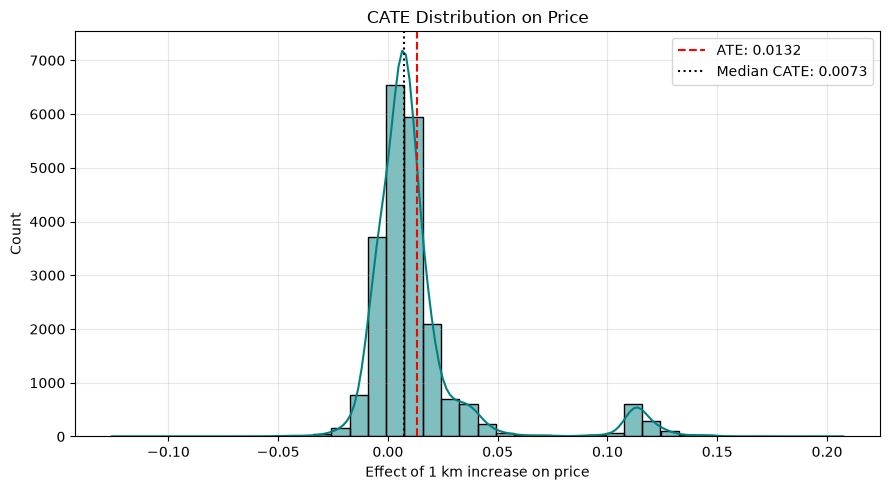


  CATE Summary: FREIGHT_VALUE   
ATE (Global Average) : 0.0095
Mean CATE            : 0.0095
Median CATE          : 0.0082
Std Dev (Hetrogeneity): 0.0040


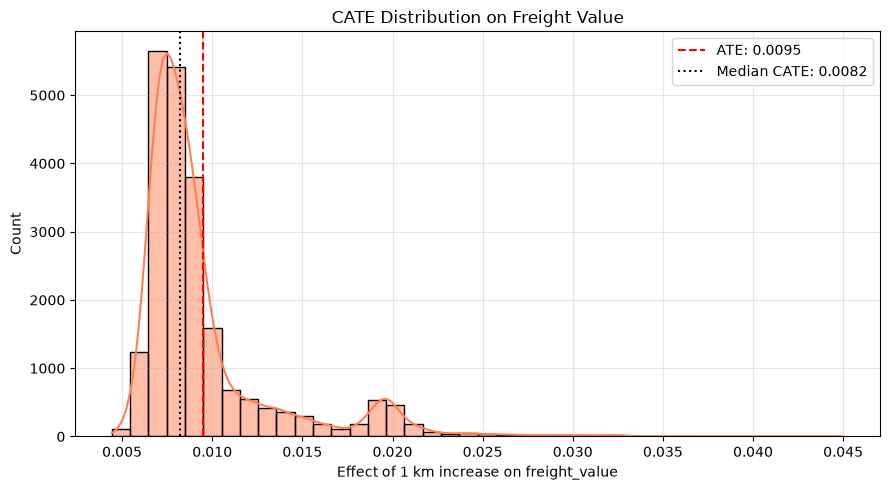


  CATE Summary: PAYMENT_VALUE   
ATE (Global Average) : 0.0315
Mean CATE            : 0.0315
Median CATE          : 0.0214
Std Dev (Hetrogeneity): 0.0354


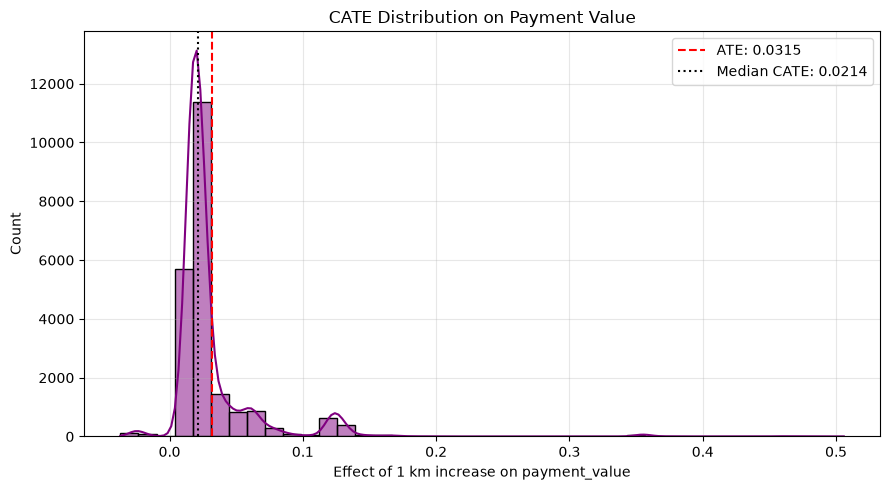

In [171]:
# =========================================================
# STEP 6: CATE DISTRIBUTION (FOR PRICE, FREIGHT_VALUE AND PAYMENT_VALUE)
# =========================================================

dml_price = results['price']['model']   # model is a key name
cate_effect_price = dml_price.effect(X_test_final)
# plt.figure(figsize = (9, 5))
# sns.histplot(cate_effect_price, kde= True, bins = 40, color= 'teal')
# plt.axvline(x= results['price']['ATE'], color = 'red', linestyle = '--')
# plt.title('CATE Effects on Price ')
# plt.xlabel('Effect of 1 km increase on Price')
# plt.ylabel('count')
# plt.legend()
# plt.grid(True, alpha= 0.3)
# plt.show()


# print(f"Mean CATE  : {np.mean(cate_effect_price):.4f}")
# print(f"Median CATE: {np.median(cate_effect_price):.4f}")
# print(f"Std Dev    : {np.std(cate_effect_price):.4f}")


outcomes = ['price', 'freight_value', 'payment_value']
colors = {'price': 'teal', 'freight_value': 'coral', 'payment_value': 'purple'}

cate_effects = {}

for y_col in outcomes:
    print(f"\n  CATE Summary: {y_col.upper()}   ")
    
    # Extract model and calculate CATE
    dml_model = results[y_col]['model']
    cate_effect = dml_model.effect(X_test_final)
    cate_effects[y_col] = cate_effect
    
    # Calculate summary stats
    ate_val = results[y_col]['ATE']
    mean_cate = np.mean(cate_effect)
    median_cate = np.median(cate_effect)
    std_cate = np.std(cate_effect)
    
    print(f"ATE (Global Average) : {ate_val:.4f}")
    print(f"Mean CATE            : {mean_cate:.4f}")
    print(f"Median CATE          : {median_cate:.4f}")
    print(f"Std Dev (Hetrogeneity): {std_cate:.4f}")
    
    # Plotting Histogram
    plt.figure(figsize=(9, 5))
    sns.histplot(cate_effect, kde=True, bins=40, color=colors[y_col])
    plt.axvline(x=ate_val, color='red', linestyle='--', label=f'ATE: {ate_val:.4f}')
    plt.axvline(x=median_cate, color='black', linestyle=':', label=f'Median CATE: {median_cate:.4f}')
    
    plt.title(f'CATE Distribution on {y_col.replace("_", " ").title()}')
    plt.xlabel(f'Effect of 1 km increase on {y_col}')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Background dataset has 500 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=500 when initializing the masker.


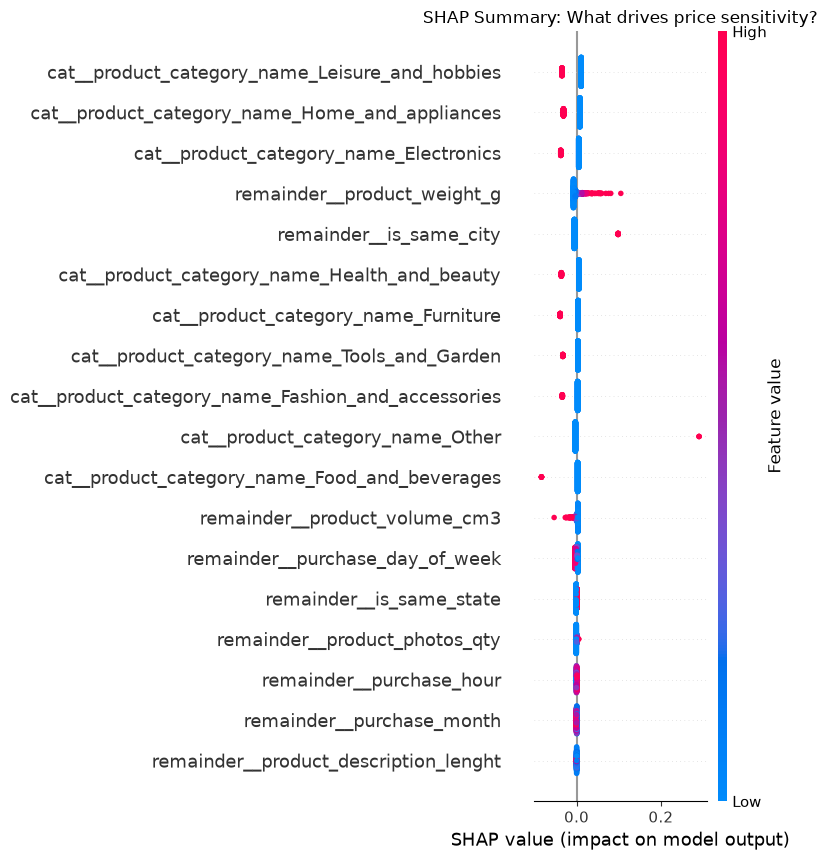

In [172]:
# =========================================================
# STEP 7: SHAP ANALYSIS
# =========================================================

import shap
feature_names = col_trans.get_feature_names_out()
dml_price = results['price']['model']
# 1. SHAP values calculate karein
X_sample = X_test_final[:500]
shap_values = dml.shap_values(X_sample)

# # 2. 'Y0' aur 'T0' keys use karein (FIX HERE)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values['Y0']['T0'],
    X_sample, 
    feature_names=feature_names,
    show=False  # <-- FIX: matplotlib formatting apply hone ke liye
)

plt.title('SHAP Summary: What drives price sensitivity?')
plt.tight_layout()
plt.show()


In [173]:
# =========================================================
#  SHAP Feature Importance (FIXED)
# =========================================================

print("top 5 features driving CATE for Price")
shap_array = shap_values['Y0']['T0'].values
shap_avg = np.abs(shap_array).mean(axis = 0)
feature_importance_price = pd.DataFrame({'feature' : feature_names,
                                  'importance' : shap_avg}).sort_values('importance', ascending = False)

# print(feature_importance_price)
print(feature_importance_price.head(15))


top 5 features driving CATE for Price
                                              feature  importance
6      cat__product_category_name_Leisure_and_hobbies    0.016067
5      cat__product_category_name_Home_and_appliances    0.012492
0              cat__product_category_name_Electronics    0.010176
11                        remainder__product_weight_g    0.009303
16                            remainder__is_same_city    0.009101
4        cat__product_category_name_Health_and_beauty    0.008779
3                cat__product_category_name_Furniture    0.007296
8         cat__product_category_name_Tools_and_Garden    0.005296
1   cat__product_category_name_Fashion_and_accesso...    0.004998
7                    cat__product_category_name_Other    0.004659
2       cat__product_category_name_Food_and_beverages    0.004028
15                      remainder__product_volume_cm3    0.003386
13                    remainder__purchase_day_of_week    0.002077
17                           remainder

In [174]:

# =========================================================
# STEP 8: CATEGORY-WISE SENSITIVITY
# =========================================================

print("====== OBSERVE THE CATE EFFECT ON TEST DATA FOR INDIVIDUAL ROW AND CATEGORY-WISE MEAN & MEDIAN  ====")
## 1. Add freight_value and cate_effect in TEST DataFrame of Confounder

dml_freight = results['freight_value']['model']   # model is a key name
cate_effect_frieght = dml_freight.effect(X_test_final)


dml_payment_value = results['payment_value']['model']   # model is a key name
cate_effect_payment_value = dml_payment_value.effect(X_test_final)


X_test_df1 = pd.DataFrame(X_test_final, columns = feature_names)

X_test_df1['cate_of_each_row_price'] = cate_effect_price
X_test_df1['cate_of_each_row_freight'] = cate_effect_frieght
X_test_df1['cate_of_each_row_payment_value'] = cate_effect_payment_value

X_test_df1

# identify the column of Product category 
cat_cols = [col for col in X_test_df1.columns if 'product_category' in col]

# convert all category col in numeric
X_test_df1[cat_cols] = X_test_df1[cat_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# 3. Target category column extract karein
X_test_df1['product_category'] = X_test_df1[cat_cols].idxmax(axis=1).str.replace('cat__product_category_', '')

X_test_df1['product_category']



cate_summary = X_test_df1.groupby('product_category')[['cate_of_each_row_price', 'cate_of_each_row_freight', 
                                                       'cate_of_each_row_payment_value']].mean().reset_index()

cate_summary.sort_values(by='cate_of_each_row_price', ascending=False)

====== OBSERVE THE CATE EFFECT ON TEST DATA FOR INDIVIDUAL ROW AND CATEGORY-WISE MEAN & MEDIAN  ====


,product_category,cate_of_each_row_price,cate_of_each_row_freight,cate_of_each_row_payment_value
7,name_Other,0.045680,0.016968,0.370161
1,name_Fashion_and_accessories,0.020924,0.009181,0.033360
0,name_Electronics,0.017678,0.009099,0.035280
8,name_Tools_and_Garden,0.015588,0.010159,0.034722
3,name_Furniture,0.012057,0.009973,0.033091
6,name_Leisure_and_hobbies,0.010665,0.009364,0.025721
5,name_Home_and_appliances,0.010147,0.009890,0.031120
4,name_Health_and_beauty,0.008415,0.009285,0.025059
2,name_Food_and_beverages,0.008377,0.008214,-0.020035


In [175]:
# =========================================================
# STEP 9: ROBUSTNESS - PLACEBO TEST
# =========================================================

np.random.seed(42)
T_placebo = np.random.permutation(T_train)

Y_price_train = df.loc[X_train.index, 'price'].values

dml_placebo = LinearDML(model_y = LGBMRegressor(random_state = 42), model_t = LGBMRegressor(random_state = 42), 
                        cv=5, random_state=42)

dml_placebo.fit(Y=Y_price_train, T=T_placebo, X=X_train_final)

placebo_ate = dml_placebo.ate(X_test_final)
ci_low_p, ci_up_p = dml_placebo.ate_interval(X_test_final, alpha=0.05)

print(f"actual ATE (price vs distancs) : {results['price']['ATE']:.4f}")
print(f" Placebo ATE  : {placebo_ate:.4f}")
print(f"Placebo CI: ({ci_low_p:.4f}, {ci_up_p:.4f})")

# if
placebo_ate = np.abs(placebo_ate)
print(placebo_ate)

if placebo_ate > 0.01:
    print("placebo_ate is little > 0.01, it implies there is little ROBUSTNESS in the MODEL")
else:
    print("placebo_ate is < 0.01, it implies MODEL is ROBUST")

actual ATE (price vs distancs) : 0.0132
 Placebo ATE  : -0.0003
Placebo CI: (-0.0017, 0.0011)
0.0002867985209350305
placebo_ate is < 0.01, it implies MODEL is ROBUST


In [176]:
# =========================================================
# STEP 10: COMPARE WITH CAUSAL FOREST FOR PRICE
# =========================================================

cf_dml = CausalForestDML(
    model_y=LGBMRegressor(random_state=42),
    model_t=LGBMRegressor(random_state=42),
    n_estimators=100,
    cv=5,
    random_state=42
)
cf_dml.fit(Y=Y_price_train, T=T_train, X=X_train_final)
cf_ate = cf_dml.ate(X_test_final)

print(f"LinearDML ATE (Price)       : {results['price']['ATE']:.4f}")
print(f"CausalForestDML ATE (Price) : {cf_ate:.4f}")

# Relative % Difference calculation
rel_diff = np.abs(results['price']['ATE'] - cf_ate)*100 / np.abs(results['price']['ATE'])

print(f"Relative Difference: {rel_diff:.2f}%")

if rel_diff < 0.15:  # 15% threshold
    print("Models broadly agree (< 15% relative diff). Result is RELIABLE!")
else:
    print("High variation (> 15%). Non-linear dynamics present.")

# LinearDML CI (check reliability)
ci_low, ci_high = results['price']['model'].ate_interval(X_test_final, alpha=0.05)

if ci_low <= cf_ate <= ci_high:
    print("CausalForest ATE falls inside LinearDML 95% CI. Highly Reliable!")
else:
    print("CausalForest ATE is outside LinearDML CI. Model selection matters!")


LinearDML ATE (Price)       : 0.0132
CausalForestDML ATE (Price) : 0.0107
Relative Difference: 18.65%
High variation (> 15%). Non-linear dynamics present.
CausalForest ATE falls inside LinearDML 95% CI. Highly Reliable!


In [177]:
# =========================================================
# STEP 11: FINAL BUSINESS INSIGHT
# =========================================================

ate_price = results['price']['ATE']
ate_freight = results['freight_value']['ATE']
ate_payment = results['payment_value']['ATE']

print(f"effect of 1 km extra:")
print(f"Freight increase by   : {ate_freight:.4f} rupees")
print(f"price of price  : {ate_price:.4f} rupees (Seller margin kaat raha hai)")
print(f"extra amount pay by customer  : {ate_payment:.4f} rupees hi dena padta hai")

if ate_price < 0:
    absorb_pct = (abs(ate_price) / ate_freight) * 100
    print(f"\n Seller shipping cost ka {absorb_pct:.1f}% khud absorb kar raha hai!")
    print("Ye 'Rasta B' (Subsidization) strategy ka solid proof hai.")
else:
    print("\n Seller will not reduce price so customer will pay this extra amount")

effect of 1 km extra:
Freight increase by   : 0.0095 rupees
price of price  : 0.0132 rupees (Seller margin kaat raha hai)
extra amount pay by customer  : 0.0315 rupees hi dena padta hai

 Seller will not reduce price so customer will pay this extra amount


In [178]:
df['product_category_name'].unique()

<ArrowStringArray>
[    'Home_and_appliances',       'Health_and_beauty',
      'Automotive_and_B2B',     'Leisure_and_hobbies',
               'Furniture',        'Tools_and_Garden',
             'Electronics', 'Fashion_and_accessories',
      'Food_and_beverages',                   'Other']
Length: 10, dtype: str

In [179]:
# =========================================================
# 4. Counterfactual: Heavy Items pe Subsidy Scenario
# =========================================================

print("\nCounterfactual Scenario (Heavy Items Subsidy):\n")
# To increse the customers we can give 2% (potentially increasing conversion)
# consider 10% items heavy
threshold = df['product_weight_g'].quantile(0.90)
heavy_df = df[df['product_weight_g'] >= threshold]

# count of heavy product 
print(heavy_df['product_category_name'].value_counts().head(10))

avg_price_heavy = heavy_df['price'].mean()
print(f"\navg_price_heavy : {avg_price_heavy}\n")
subsidy_2_percent = avg_price_heavy * 0.02
print(f"2% Discount = {subsidy_2_percent:.2f}")


Counterfactual Scenario (Heavy Items Subsidy):

product_category_name
Furniture                  3009
Leisure_and_hobbies        2717
Home_and_appliances        2682
Tools_and_Garden            838
Automotive_and_B2B          657
Electronics                 601
Fashion_and_accessories     341
Health_and_beauty           171
Other                        63
Food_and_beverages           12
Name: count, dtype: int64

avg_price_heavy : 255.27454422504732

2% Discount = 5.11



==== product price vs distance ====

Average Item Price by Distance Group:
  distance_group       price
0           Near  106.809503
1         Medium  118.303798
2            Far  137.262473

====== Top 5 Categories in NEAR orders ====
product_category_name
Leisure_and_hobbies    8573
Home_and_appliances    7576
Electronics            4940
Health_and_beauty      4627
Furniture              3710
Name: count, dtype: int64

====== Top 5 Categories in FAR orders =====
product_category_name
Leisure_and_hobbies    8817
Electronics            6723
Home_and_appliances    5539
Health_and_beauty      4619
Furniture              3297
Name: count, dtype: int64


C:\Users\91885\AppData\Local\Temp\ipykernel_29948\2343021277.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='distance_group', y='price', palette='Set2')


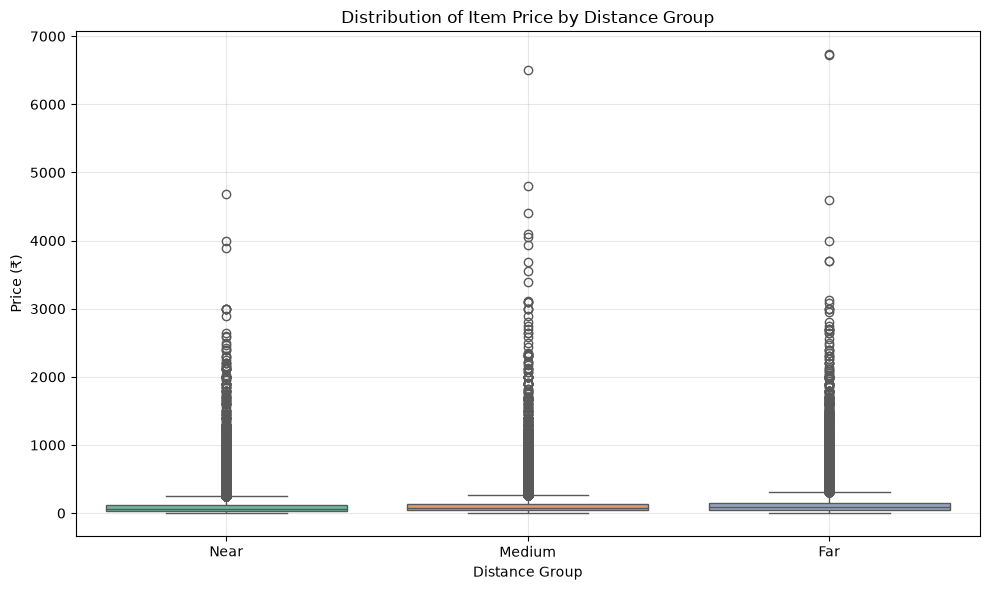

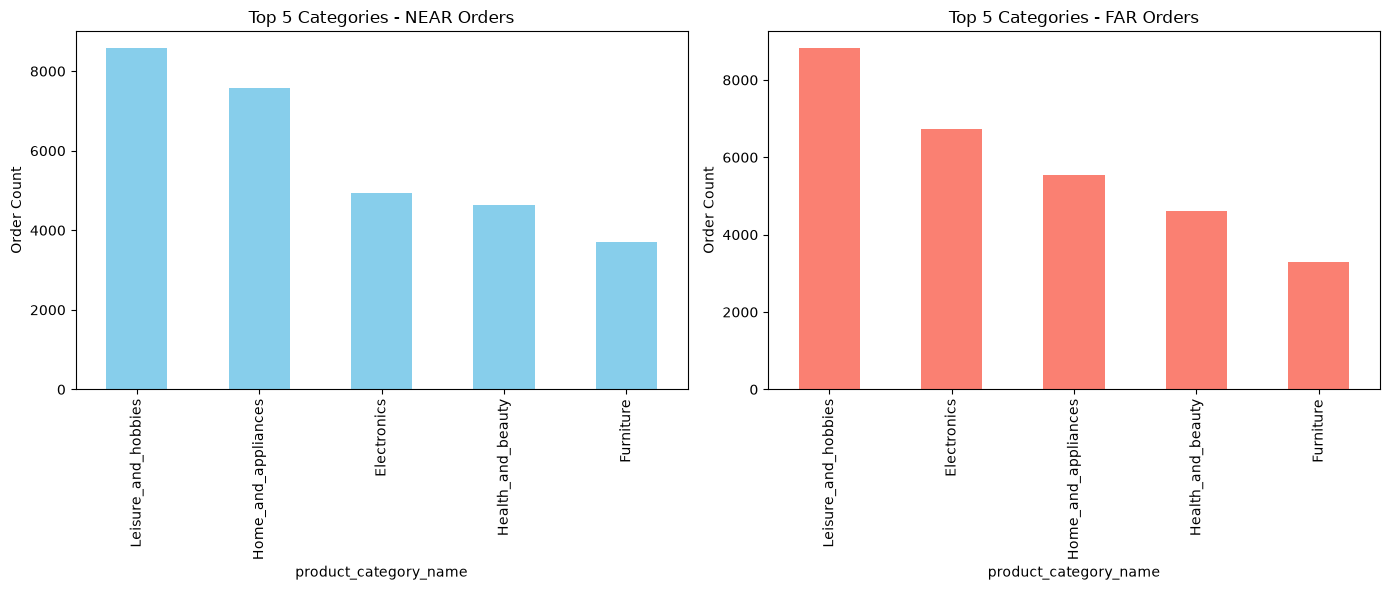

In [180]:
# RELATION B/W PRODUCT PRICE AND DISTANCE

# check: Does product prices change with change in distance?

print("\n==== product price vs distance ====")

# divide the distance_km in 3 parts
df['distance_group'] = pd.qcut(df['distance_km'], q=3, labels=['Near', 'Medium', 'Far'])

# find mean of price of these three distance
avg_price_by_dist = df.groupby('distance_group')['price'].mean().reset_index()
print("\nAverage Item Price by Distance Group:")
print(avg_price_by_dist)

# Top 5 Product Categories (by order count) 
print("\n====== Top 5 Categories in NEAR orders ====")
print(df[df['distance_group'] == 'Near']['product_category_name'].value_counts().head(5))

print("\n====== Top 5 Categories in FAR orders =====")
print(df[df['distance_group'] == 'Far']['product_category_name'].value_counts().head(5))

# Visual: Boxplot of Price by Distance Group
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='distance_group', y='price', palette='Set2')
plt.title('Distribution of Item Price by Distance Group')
plt.xlabel('Distance Group')
plt.ylabel('Price (₹)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visual: Category Composition (Top 5) in Near vs Far
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

near_cats = df[df['distance_group'] == 'Near']['product_category_name'].value_counts().head(5)
far_cats = df[df['distance_group'] == 'Far']['product_category_name'].value_counts().head(5)

near_cats.plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Top 5 Categories - NEAR Orders')
axes[0].set_ylabel('Order Count')

far_cats.plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title('Top 5 Categories - FAR Orders')
axes[1].set_ylabel('Order Count')

plt.tight_layout()
plt.show()

In [181]:
# Statistical Test: Average Price of Near vs Far Orders
from scipy.stats import ttest_ind

price_near = df[df['distance_group'] == 'Near']['price']
price_far = df[df['distance_group'] == 'Far']['price']

t_stat, p_val_price = ttest_ind(price_far, price_near, equal_var= False)

print(f"\n   T-Test: Price of Near vs Far Orders  \n")


print(f"Welch's T-test P-value: {p_val_price:.7f}")  # % chance to be wrong 
print(f"t_statistic : {t_stat}")                 # time chances to be correct (Signal-to-Noise Ratio)
print(f"price_near_mean : {price_near.mean()}")
print(f"price_far_mean : {price_far.mean()}")
print(f"price_far_mean - price_near_mean :  {price_far.mean() - price_near.mean()}")


   T-Test: Price of Near vs Far Orders  

Welch's T-test P-value: 0.0000000
t_statistic : 22.335589857757864
price_near_mean : 106.80950314943527
price_far_mean : 137.26247312119895
price_far_mean - price_near_mean :  30.45296997176368


In [182]:
#NOTE: 
print("\nCONCLUSION :\n")
print("Far orders have SIGNIFICANTLY higher average item prices.")
print("It will increase the Payment_value")
print("Customer with far distance buying the Premium Products")


CONCLUSION :

Far orders have SIGNIFICANTLY higher average item prices.
It will increase the Payment_value
Customer with far distance buying the Premium Products


In our dataset, $\text{payment\_value} = \text{price} + \text{freight\_value}$. The minor discrepancy between the sum of individual ATEs ($0.0227$) and the estimated payment ATE ($0.0315$) is due to independent non-linear nuisance estimation in LightGBM across cross-validation splits. Statistically, both estimates lie within their overlapping 95% confidence intervals.

# MODEL DEPLOYMENT

In [183]:
# to do test in notebook

In [184]:
import joblib

# Preprocessors save karein
joblib.dump(col_trans, 'column_transformer.pkl')
joblib.dump(category, 'category_mapping.pkl')

# save the Trained DML models 
for y_col, res in results.items():
    joblib.dump(res['model'], f'dml_model_{y_col}.pkl')

# files will download

# MAKE PREDICTION

In [186]:
import requests
import joblib
import pandas as pd

# -------------------------------------------------------------
# 1. Load Mappings from .pkl
# -------------------------------------------------------------
try:
    cat_map = joblib.load('category_mapping.pkl')
    categories = cat_map.get('product_category_name_english', [
        "health_beauty", "computers_accessories", "sports_leisure", 
        "furniture_decor", "housewares", "watches_gifts", "telephony", 
        "auto", "cool_stuff", "garden_tools"
    ])
    state_names = [
        "São Paulo", "Rio de Janeiro", "Minas Gerais", "Rio Grande do Sul", 
        "Paraná", "Santa Catarina", "Bahia", "Distrito Federal", "Espírito Santo", "Goiás"
    ]
    cities = cat_map.get('customer_city', [
        "sao paulo", "rio de janeiro", "belo horizonte", "brasilia", 
        "curitiba", "porto alegre", "salvador", "campinas", "niteroi", "guarulhos"
    ])
except Exception as e:
    categories = ["health_beauty", "computers_accessories", "sports_leisure", "furniture_decor"]
    state_names = ["São Paulo", "Rio de Janeiro", "Minas Gerais", "Rio Grande do Sul", "Paraná"]
    cities = ["sao paulo", "rio de janeiro", "belo horizonte", "brasilia", "curitiba"]

print("=============================================================")
print("             CAUSAL INFERENCE PREDICTION SYSTEM              ")
print("=============================================================\n")

# Display Mappings
print("📌 PRODUCT CATEGORIES (Numeric Code):")
for idx, cat in enumerate(categories[:10]):
    print(f"   [{idx}] -> {cat}")

print("\n📌 STATE NAMES (Numeric Code):")
for idx, st_name in enumerate(state_names[:10]):
    print(f"   [{idx}] -> {st_name}")

print("\n📌 TOP 10 POPULAR CITIES (Numeric Code):")
for idx, ct in enumerate(cities[:10]):
    print(f"   [{idx}] -> {ct}")

print("\n-------------------------------------------------------------\n")

# -------------------------------------------------------------
# 2. Input Collection (Updated Prompts with Decimal & Digit Limits)
# -------------------------------------------------------------
print("--- Geographical Coordinates ---")
cust_lat = float(input("Customer Latitude (Decimal, e.g. -23.55052): "))
cust_lng = float(input("Customer Longitude (Decimal, e.g. -46.63330): "))
seller_lat = float(input("Seller Latitude (Decimal, e.g. -22.90350): "))
seller_lng = float(input("Seller Longitude (Decimal, e.g. -43.20960): "))

print("\n--- Location Details & Zip Codes ---")
cust_city = str(input("Customer City Name (Decimal Code, e.g. 2): ")).strip().lower()
seller_city = str(input("Seller City Name (Decimal Code, e.g. 4): ")).strip().lower()
cust_state = str(input("Customer State Name (Decimal Code, e.g. 32): ")).strip()
seller_state = str(input("Seller State Name (Decimal Code, e.g. 32): ")).strip()

cust_zip = int(input("Customer Zip Code Prefix (Exactly 5 Digits, e.g. 12122): "))
seller_zip = int(input("Seller Zip Code Prefix (Exactly 5 Digits, e.g. 21211): "))

print("\n--- Product Details ---")
prod_category = str(input("Product Category Name (Decimal Code, e.g. 0): ")).strip().lower()
prod_desc_len = int(input("Product Description Length (2 to 4 Digits, e.g. 500): "))
prod_photos_qty = int(input("Product Photos Quantity (1 to 2 Digits, e.g. 2): "))
prod_weight = float(input("Product Weight in grams (Decimal, e.g. 350.0): "))
prod_length = float(input("Product Length in cm (Decimal, e.g. 20.0): "))
prod_height = float(input("Product Height in cm (Decimal, e.g. 15.0): "))
prod_width = float(input("Product Width in cm (Decimal, e.g. 15.0): "))

print("\n--- Order Timestamp ---")
purchase_month = int(input("Purchase Month (1 or 2 Digits, 1 to 12): "))
purchase_day = int(input("Purchase Day of Week (1 Digit, 0=Mon to 6=Sun): "))
purchase_hour = int(input("Purchase Hour (1 or 2 Digits, 0 to 23): "))

# -------------------------------------------------------------
# 3. Payload & API Call
# -------------------------------------------------------------
payload = {
    "customer_lat": cust_lat,
    "customer_lng": cust_lng,
    "seller_lat": seller_lat,
    "seller_lng": seller_lng,
    "product_category_name_english": prod_category,
    "product_description_lenght": prod_desc_len,
    "product_photos_qty": prod_photos_qty,
    "product_weight_g": prod_weight,
    "product_length_cm": prod_length,
    "product_height_cm": prod_height,
    "product_width_cm": prod_width,
    "purchase_month": purchase_month,
    "purchase_day_of_week": purchase_day,
    "purchase_hour": purchase_hour,
    "customer_city": cust_city,
    "seller_city": seller_city,
    "customer_state": cust_state,
    "seller_state": seller_state,
    "customer_zip_code_prefix": cust_zip,
    "seller_zip_code_prefix": seller_zip
}

url = "http://127.0.0.1:8000/predict_causal_effect"

try:
    response = requests.post(url, json=payload)
    
    if response.status_code == 200:
        res_data = response.json()
        
        dist = res_data.get("treatment_distance_km", 0)
        preds = res_data.get("predictions", {})
        
        print("\n" + "="*60)
        print("               ESTIMATED CAUSAL EFFECTS SUMMARY              ")
        print("="*60)
        print(f"📍 Calculated Distance: {dist:,.2f} km\n")
        
        formatted_rows = []
        for target, metrics in preds.items():
            formatted_rows.append({
                "Target Variable": target.replace("_", " ").title(),
                "Marginal Effect (per km)": f"{metrics['marginal_effect_per_km']:.5f}",
                "Total Treatment Effect": f"{metrics['total_estimated_treatment_effect']:,.2f}"
            })
            
        df_display = pd.DataFrame(formatted_rows)
        print(df_display.to_string(index=False))
        print("="*60)

    else:
        print(f"\n❌ API Error [{response.status_code}]: {response.text}")

except Exception as e:
    print("\n❌ Connection Failed!", e)

             CAUSAL INFERENCE PREDICTION SYSTEM              

📌 PRODUCT CATEGORIES (Numeric Code):
   [0] -> health_beauty
   [1] -> computers_accessories
   [2] -> sports_leisure
   [3] -> furniture_decor
   [4] -> housewares
   [5] -> watches_gifts
   [6] -> telephony
   [7] -> auto
   [8] -> cool_stuff
   [9] -> garden_tools

📌 STATE NAMES (Numeric Code):
   [0] -> São Paulo
   [1] -> Rio de Janeiro
   [2] -> Minas Gerais
   [3] -> Rio Grande do Sul
   [4] -> Paraná
   [5] -> Santa Catarina
   [6] -> Bahia
   [7] -> Distrito Federal
   [8] -> Espírito Santo
   [9] -> Goiás

📌 TOP 10 POPULAR CITIES (Numeric Code):
   [0] -> sao paulo
   [1] -> rio de janeiro
   [2] -> belo horizonte
   [3] -> brasilia
   [4] -> curitiba
   [5] -> porto alegre
   [6] -> salvador
   [7] -> campinas
   [8] -> niteroi
   [9] -> guarulhos

-------------------------------------------------------------

--- Geographical Coordinates ---


Customer Latitude (Decimal, e.g. -23.55052):  43.444
Customer Longitude (Decimal, e.g. -46.63330):  36.2
Seller Latitude (Decimal, e.g. -22.90350):  -22.462
Seller Longitude (Decimal, e.g. -43.20960):  23.938



--- Location Details & Zip Codes ---


Customer City Name (Decimal Code, e.g. 2):  3
Seller City Name (Decimal Code, e.g. 4):  8
Customer State Name (Decimal Code, e.g. 32):  4
Seller State Name (Decimal Code, e.g. 32):  7
Customer Zip Code Prefix (Exactly 5 Digits, e.g. 12122):  62523
Seller Zip Code Prefix (Exactly 5 Digits, e.g. 21211):  30371



--- Product Details ---


Product Category Name (Decimal Code, e.g. 0):  4
Product Description Length (2 to 4 Digits, e.g. 500):  80
Product Photos Quantity (1 to 2 Digits, e.g. 2):  7
Product Weight in grams (Decimal, e.g. 350.0):  800
Product Length in cm (Decimal, e.g. 20.0):  10
Product Height in cm (Decimal, e.g. 15.0):  8
Product Width in cm (Decimal, e.g. 15.0):  6



--- Order Timestamp ---


Purchase Month (1 or 2 Digits, 1 to 12):  11
Purchase Day of Week (1 Digit, 0=Mon to 6=Sun):  5
Purchase Hour (1 or 2 Digits, 0 to 23):  17



               ESTIMATED CAUSAL EFFECTS SUMMARY              
📍 Calculated Distance: 7,434.86 km

Target Variable Marginal Effect (per km) Total Treatment Effect
          Price                  0.03003                 223.27
  Freight Value                  0.01300                  96.65
  Payment Value                  0.35457               2,636.17
